# Análisis de Sentimiento y Polaridad en Reseñas de IMDB

**Materia:** APIT — Análisis y Procesamiento Inteligente de Textos
**Proyecto Final:** Análisis de sentimiento y polaridad en reseñas de entretenimiento

---

### Alineación con los temas del curso

| Etapa del pipeline | Tema del curso |
|---|---|
| Preproceso completo de documentos | Recuperación de Información (2.2.1) |
| Modelado léxico de polaridad con VADER | Minería de Textos (Tema 5) |
| Validación contra el *ground truth* | Medidas de Evaluación (2.2.5) |

El cuaderno está organizado de forma secuencial y modular. Cada sección encapsula una etapa
del pipeline y puede ejecutarse de forma independiente una vez cargadas las dependencias.


## 0. Instalación de dependencias y descarga de recursos

Esta celda instala las librerías del stack tecnológico y descarga los corpus que NLTK
necesita: el lexicón de **VADER**, las **stopwords** del inglés y los recursos de
**WordNet** para la lematización. Solo es necesario ejecutarla una vez por entorno.


In [1]:
# Instalación de librerías (descomentar si se ejecuta en un entorno limpio o en Colab)
# !pip install pandas nltk scikit-learn matplotlib seaborn wordcloud

import nltk

# Descarga de los recursos lingüísticos requeridos.
# - vader_lexicon: diccionario de polaridad para el analizador VADER.
# - stopwords: listas de palabras vacías (artículos, preposiciones, etc.).
# - wordnet / omw-1.4: base léxica usada por el lematizador.
for recurso in ["vader_lexicon", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(recurso, quiet=True)

print("Recursos de NLTK descargados correctamente.")


Recursos de NLTK descargados correctamente.


## 1. Importación de librerías

Centralizamos todas las importaciones para tener visibilidad del stack completo:
manipulación de datos (Pandas), procesamiento de lenguaje (NLTK + VADER),
métricas (scikit-learn) y visualización (Matplotlib, Seaborn, WordCloud).


In [2]:
import re                                  # Expresiones regulares para limpieza de texto
import string                              # Catálogo de signos de puntuación
import pandas as pd                        # Manejo del dataset en formato tabular
import numpy as np                         # Operaciones numéricas auxiliares

import matplotlib.pyplot as plt            # Gráficos base
import seaborn as sns                      # Visualización estadística (heatmap)
from wordcloud import WordCloud            # Nubes de palabras

from nltk.corpus import stopwords          # Stopwords en inglés
from nltk.stem import WordNetLemmatizer    # Lematizador basado en WordNet
from nltk.tokenize import word_tokenize    # Tokenizador (fallback con .split si falla)
from nltk.sentiment.vader import SentimentIntensityAnalyzer  # Analizador léxico VADER

# Métricas de evaluación supervisada
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Configuración estética global para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 2. Datos simulados (*mock data*)

Para que el cuaderno sea ejecutable de inmediato sin depender del archivo CSV real,
definimos un pequeño conjunto de reseñas de ejemplo. Mantiene exactamente la misma
estructura del dataset original: las columnas `review` (texto libre en inglés) y
`sentiment` (etiqueta real `positive` / `negative`).


In [3]:
# Bloque de datos simulados con la misma estructura que IMDB_Dataset.csv.
# Sirve como respaldo para probar el pipeline completo de extremo a extremo.
mock_data = {
    "review": [
        "This movie was absolutely fantastic! The acting was brilliant and the plot kept me hooked.",
        "Worst film I have ever seen. Boring, predictable and a complete waste of my time.",
        "A masterpiece of modern cinema. Beautiful cinematography and a deeply moving story.",
        "Terrible script and wooden performances. I could not wait for it to end.",
        "I really enjoyed this one. Funny, heartwarming and surprisingly clever throughout.",
    ],
    "sentiment": [
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
    ],
}

df_mock = pd.DataFrame(mock_data)
df_mock


,review,sentiment
0,This movie was absolutely fantastic! The actin...,positive
1,"Worst film I have ever seen. Boring, predictab...",negative
2,A masterpiece of modern cinema. Beautiful cine...,positive
3,Terrible script and wooden performances. I cou...,negative
4,"I really enjoyed this one. Funny, heartwarming...",positive


## 3. Carga y Exploración del dataset
### (Recuperación de Información — Tema 2.2.1)

Intentamos cargar el archivo real `dataset/IMDB_Dataset.csv`. Si no se encuentra
(por ejemplo, al ejecutar el cuaderno por primera vez), recurrimos automáticamente
a los datos simulados de la celda anterior. Posteriormente realizamos la limpieza
estructural básica: eliminación de registros nulos y duplicados.


In [4]:
# Carga robusta: usa el CSV real si existe; en caso contrario, los datos simulados.
RUTA_CSV = "dataset/IMDB Dataset.csv"

try:
    df = pd.read_csv(RUTA_CSV)
    print(f"Dataset real cargado desde '{RUTA_CSV}'.")
except FileNotFoundError:
    df = df_mock.copy()
    print("Archivo no encontrado. Se utilizan los datos simulados (mock data).")

print(f"Dimensiones iniciales: {df.shape[0]} filas, {df.shape[1]} columnas.")
df.head()


Dataset real cargado desde 'dataset/IMDB Dataset.csv'.
Dimensiones iniciales: 50000 filas, 2 columnas.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Exploración inicial: tipos de datos y conteo de la variable objetivo.
print("Información general del DataFrame:")
df.info()

print("\nDistribución de la etiqueta real (sentiment):")
print(df["sentiment"].value_counts())


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Distribución de la etiqueta real (sentiment):
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
# Limpieza estructural del dataset.
filas_iniciales = len(df)

# 1) Eliminamos filas con valores nulos en cualquiera de las dos columnas.
df = df.dropna(subset=["review", "sentiment"])

# 2) Eliminamos reseñas duplicadas, que sesgarían el análisis.
df = df.drop_duplicates(subset=["review"])

# 3) Reiniciamos el índice tras los borrados para mantener la consistencia.
df = df.reset_index(drop=True)

print(f"Filas eliminadas (nulos + duplicados): {filas_iniciales - len(df)}")
print(f"Filas restantes: {len(df)}")


Filas eliminadas (nulos + duplicados): 418
Filas restantes: 49582


## 4. Preproceso de Documentos
### (Recuperación de Información — Tema 2.2.1)

Encapsulamos el preproceso en una función reutilizable. Cada documento (reseña)
atraviesa la cadena clásica de normalización:

1. **Conversión a minúsculas** para unificar el vocabulario.
2. **Eliminación de etiquetas HTML** (frecuentes en el dataset de IMDB, como `<br />`).
3. **Eliminación de signos de puntuación y caracteres especiales** dejando solo letras.
4. **Tokenización** del texto en palabras.
5. **Eliminación de stopwords** del inglés, que aportan poco valor semántico,
   pero **conservando las partículas de negación** (*not*, *no*, *never*...), que
   sí invierten la polaridad y son críticas para el análisis de sentimiento.
6. **Lematización** para reducir cada palabra a su forma canónica (raíz léxica).

El resultado se almacena en la nueva columna `review_limpia`.


In [7]:
# Inicializamos una sola vez los objetos pesados (stopwords y lematizador)
# para no recrearlos en cada llamada a la función.
stop_words_en = set(stopwords.words("english"))

# --- Ajuste crítico para análisis de sentimiento ---
# La lista por defecto de NLTK incluye partículas de negación (not, no, nor...).
# Eliminarlas invierte el sentido de una frase: "not good" quedaría como "good",
# lo que genera falsos positivos al pasar el texto por VADER. Las conservamos
# restándolas del conjunto de stopwords antes de filtrar.
# (Nota: las contracciones como "doesn't" ya se degradan al quitar la puntuación
#  en el paso 3; por eso el rescate efectivo se limita a las negaciones simples.
#  Esta es, además, una razón más para evaluar VADER sobre el texto crudo, abajo.)
negaciones = {"no", "nor", "not", "never", "none", "nothing", "neither",
              "hardly", "scarcely", "barely", "without"}
stop_words_en = stop_words_en - negaciones

lematizador = WordNetLemmatizer()


def preprocesar_texto(texto):
    """Normaliza un documento de texto aplicando la cadena de preproceso completa.

    Parámetros
    ----------
    texto : str
        Reseña original en lenguaje natural.

    Retorna
    -------
    str
        Texto limpio, sin stopwords y con cada palabra lematizada.
    """
    # 1) Minúsculas
    texto = str(texto).lower()

    # 2) Eliminación de etiquetas HTML (ej. <br />)
    texto = re.sub(r"<.*?>", " ", texto)

    # 3) Conservamos únicamente letras y espacios; se eliminan signos y números.
    texto = re.sub(r"[^a-z\s]", " ", texto)

    # 4) Tokenización en palabras. Usamos un fallback con split() por robustez.
    try:
        tokens = word_tokenize(texto)
    except LookupError:
        tokens = texto.split()

    # 5 y 6) Filtramos stopwords y lematizamos cada token superviviente.
    tokens_limpios = [
        lematizador.lemmatize(palabra)
        for palabra in tokens
        if palabra not in stop_words_en and len(palabra) > 2
    ]

    # Reconstruimos el documento como una cadena de tokens separados por espacios.
    return " ".join(tokens_limpios)


# Aplicamos la función a toda la columna 'review' y guardamos en 'review_limpia'.
df["review_limpia"] = df["review"].apply(preprocesar_texto)

# Comparamos el texto original con el preprocesado para verificar el resultado.
df[["review", "review_limpia"]].head()


,review,review_limpia
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode hooked...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


## 5. Análisis de Sentimiento con VADER
### (Minería de Textos — Tema 5)

Aplicamos el analizador léxico **VADER** (*Valence Aware Dictionary and sEntiment
Reasoner*), que asigna a cada documento un puntaje compuesto (`compound`) en el
rango **[-1, 1]**. Clasificamos con el umbral estándar del proyecto: un puntaje
mayor o igual a `0.05` se considera **positive** y por debajo de ese valor,
**negative**, ignorando los neutrales para alinear la salida con las dos clases
del dataset original.

**Consideración metodológica clave.** VADER no es un modelo estadístico que se
entrene con los datos, sino un sistema heurístico basado en reglas. Una parte
importante de su precisión proviene de señales que el preproceso clásico destruye:
interpreta las **MAYÚSCULAS** como énfasis, la **puntuación** repetida (`!!!`)
como intensidad y, sobre todo, maneja explícitamente las **negaciones** invirtiendo
la polaridad de lo que las sigue. Al pasarle `review_limpia` (en minúsculas, sin
puntuación y lematizado) le retiramos justamente las pistas que mejor sabe leer.

Por eso aquí ejecutamos **dos versiones** del análisis y las comparamos:

- **(A) Enfoque del enunciado:** VADER sobre `review_limpia`, el texto totalmente
  preprocesado. Sirve como *línea base*.
- **(B) Enfoque mejorado:** VADER sobre el texto crudo al que solo se le quitaron las
  etiquetas HTML, preservando mayúsculas, puntuación y negaciones.

La comparación de exactitudes (sección 6) cuantifica el impacto de esta decisión de
diseño en lugar de afirmarlo de forma teórica.


In [8]:
# Limpieza LIGERA pensada específicamente para VADER: a diferencia del preproceso
# clásico, conserva mayúsculas, signos de puntuación y negaciones, porque son las
# señales de intensidad y polaridad que el modelo heurístico aprovecha.
def limpiar_para_vader(texto):
    """Limpieza mínima para VADER: elimina HTML y normaliza espacios, nada más."""
    texto = str(texto)
    texto = re.sub(r"<.*?>", " ", texto)        # quita etiquetas HTML (ej. <br />)
    texto = re.sub(r"\s+", " ", texto).strip()  # normaliza espacios en blanco
    return texto


# Nueva columna con el texto apenas saneado, lista para el enfoque (B).
df["review_vader"] = df["review"].apply(limpiar_para_vader)

df[["review", "review_vader"]].head()


,review,review_vader
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. The filming tec...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is..."


In [9]:
# Instanciamos el analizador de intensidad de sentimiento de VADER.
analizador_vader = SentimentIntensityAnalyzer()


def calcular_polaridad(texto):
    """Devuelve el puntaje compuesto (compound) de VADER para un texto dado."""
    return analizador_vader.polarity_scores(texto)["compound"]


# (A) Enfoque del enunciado: VADER sobre el texto totalmente preprocesado.
df["score_limpia"] = df["review_limpia"].apply(calcular_polaridad)
df["sent_limpia"] = np.where(df["score_limpia"] >= 0.05, "positive", "negative")

# (B) Enfoque mejorado: VADER sobre el texto crudo (solo sin HTML).
#     Estas dos columnas (pred_score / pred_sentiment) son las que alimentan
#     el resto del cuaderno (evaluación y nubes de palabras).
df["pred_score"] = df["review_vader"].apply(calcular_polaridad)
df["pred_sentiment"] = np.where(df["pred_score"] >= 0.05, "positive", "negative")

# Vista de control comparando ambos enfoques contra la etiqueta real.
df[["review_vader", "score_limpia", "sent_limpia",
    "pred_score", "pred_sentiment", "sentiment"]].head()


,review_vader,score_limpia,sent_limpia,pred_score,pred_sentiment,sentiment
0,One of the other reviewers has mentioned that ...,-0.9891,negative,-0.9951,negative,positive
1,A wonderful little production. The filming tec...,0.9502,positive,0.9641,positive,positive
2,I thought this was a wonderful way to spend ti...,0.9562,positive,0.9780,positive,positive
3,Basically there's a family where a little boy ...,-0.9259,negative,-0.8819,negative,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",0.9816,positive,0.9803,positive,positive


## 6. Evaluación del Modelo
### (Medidas de Evaluación — Tema 2.2.5)

Comparamos la predicción del modelo (`pred_sentiment`) contra la etiqueta real
(`sentiment`, el *ground truth*). Empezamos contrastando las dos variantes de la
sección anterior para medir el efecto del preproceso, y luego desglosamos las
métricas del enfoque que alimenta el resto del cuaderno (el de texto crudo):

- **Accuracy** (exactitud global).
- **Reporte de clasificación** con *Precision*, *Recall* y *F1-score* por clase.
- **Matriz de confusión** que cruza valores reales contra predichos.


In [10]:
# Comparación directa del impacto del preproceso sobre la exactitud de VADER.
acc_limpia = accuracy_score(df["sentiment"], df["sent_limpia"])
acc_crudo = accuracy_score(df["sentiment"], df["pred_sentiment"])

print("Impacto del preproceso en la exactitud de VADER")
print("-" * 52)
print(f"(A) VADER sobre texto preprocesado (review_limpia): {acc_limpia:.4f}")
print(f"(B) VADER sobre texto crudo (solo sin HTML):        {acc_crudo:.4f}")
print(f"Diferencia (B - A):                                 {acc_crudo - acc_limpia:+.4f}")


Impacto del preproceso en la exactitud de VADER
----------------------------------------------------
(A) VADER sobre texto preprocesado (review_limpia): 0.6814
(B) VADER sobre texto crudo (solo sin HTML):        0.6992
Diferencia (B - A):                                 +0.0178


In [11]:
# Definimos el orden de las clases para que las métricas y la matriz sean consistentes.
etiquetas = ["negative", "positive"]

# Usamos el enfoque (B), VADER sobre texto crudo, como modelo final del cuaderno.
y_real = df["sentiment"]
y_pred = df["pred_sentiment"]

# Exactitud global del modelo.
exactitud = accuracy_score(y_real, y_pred)
print(f"Accuracy (Exactitud global): {exactitud:.4f}\n")

# Reporte detallado con precision, recall y f1 por cada clase.
print("Reporte de clasificación:")
print(classification_report(y_real, y_pred, labels=etiquetas, zero_division=0))

# Matriz de confusión en formato de arreglo (filas = real, columnas = predicho).
matriz = confusion_matrix(y_real, y_pred, labels=etiquetas)
print("Matriz de confusión (filas = real, columnas = predicho):")
print(matriz)


Accuracy (Exactitud global): 0.6992

Reporte de clasificación:
              precision    recall  f1-score   support

    negative       0.79      0.54      0.64     24698
    positive       0.65      0.86      0.74     24884

    accuracy                           0.70     49582
   macro avg       0.72      0.70      0.69     49582
weighted avg       0.72      0.70      0.69     49582

Matriz de confusión (filas = real, columnas = predicho):
[[13391 11307]
 [ 3606 21278]]


## 7. Visualización de Resultados

Generamos tres visualizaciones complementarias para interpretar el desempeño del
modelo y la naturaleza del corpus.


### 7.1 Mapa de calor de la Matriz de Confusión

El *heatmap* permite identificar rápidamente los aciertos (diagonal principal) y los
errores de clasificación (falsos positivos y falsos negativos).


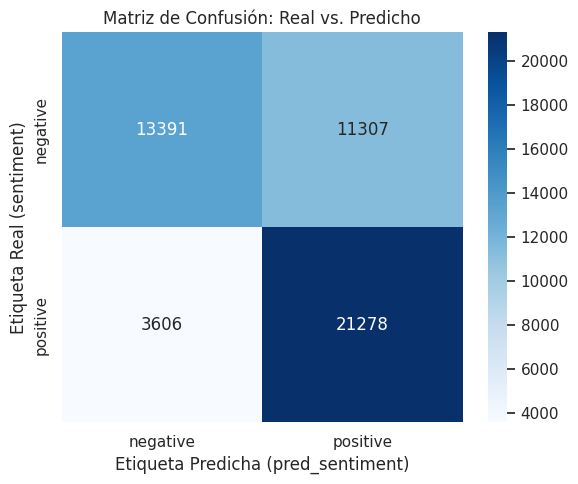

In [12]:
plt.figure(figsize=(6, 5))

# Representamos la matriz de confusión como un mapa de calor anotado.
sns.heatmap(
    matriz,
    annot=True,            # Muestra el conteo numérico en cada celda
    fmt="d",               # Formato entero
    cmap="Blues",          # Paleta de color
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    cbar=True,
)

plt.title("Matriz de Confusión: Real vs. Predicho")
plt.xlabel("Etiqueta Predicha (pred_sentiment)")
plt.ylabel("Etiqueta Real (sentiment)")
plt.tight_layout()
plt.show()


### 7.2 Histograma de la distribución de puntajes de polaridad

Visualiza cómo se reparten los valores `compound` de VADER en todo el corpus.
La línea vertical marca el umbral de decisión (0.05) que separa las clases.


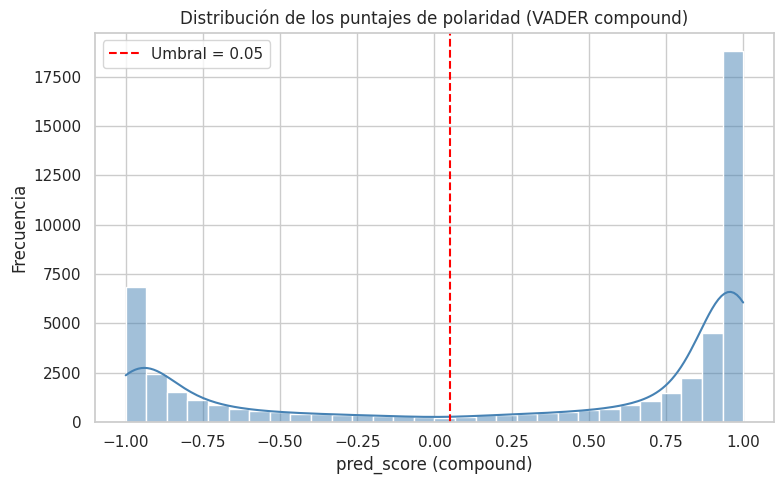

In [13]:
plt.figure(figsize=(8, 5))

# Histograma de la columna numérica de polaridad.
sns.histplot(df["pred_score"], bins=30, kde=True, color="steelblue")

# Línea de referencia en el umbral de clasificación.
plt.axvline(0.05, color="red", linestyle="--", label="Umbral = 0.05")

plt.title("Distribución de los puntajes de polaridad (VADER compound)")
plt.xlabel("pred_score (compound)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


### 7.3 Nubes de palabras por clase predicha

Construimos dos nubes de palabras a partir de `review_limpia`: una con las reseñas
que el modelo clasificó como **positivas** y otra con las **negativas**. Esto revela
el vocabulario más representativo de cada polaridad según la predicción.


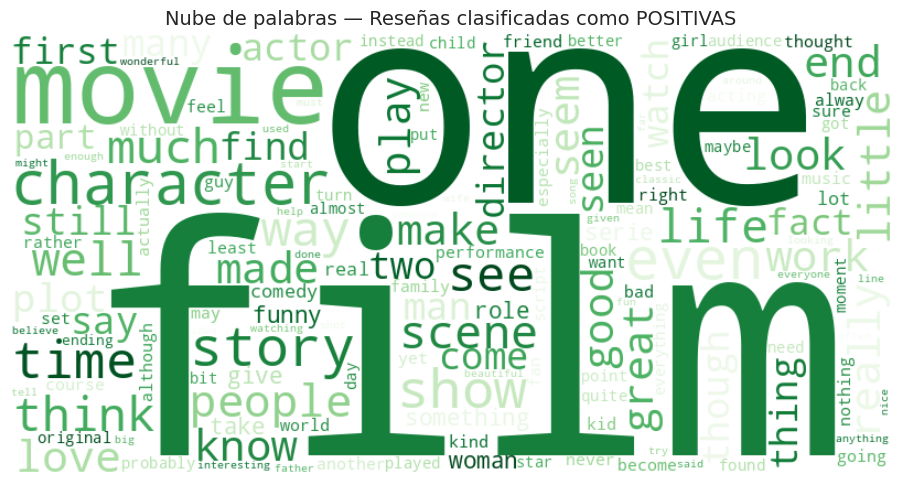

In [14]:
# Concatenamos todo el texto limpio de cada clase predicha en un único string.
texto_positivo = " ".join(df.loc[df["pred_sentiment"] == "positive", "review_limpia"])
texto_negativo = " ".join(df.loc[df["pred_sentiment"] == "negative", "review_limpia"])


def generar_wordcloud(texto, titulo, colormap):
    """Genera y muestra una nube de palabras a partir de un texto dado."""
    # WordCloud falla si el texto está vacío; lo controlamos para evitar errores.
    if not texto.strip():
        print(f"No hay texto disponible para: {titulo}")
        return

    nube = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=150,
    ).generate(texto)

    plt.figure(figsize=(10, 5))
    plt.imshow(nube, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()


# Nube de palabras de las reseñas predichas como POSITIVAS.
generar_wordcloud(
    texto_positivo,
    "Nube de palabras — Reseñas clasificadas como POSITIVAS",
    "Greens",
)


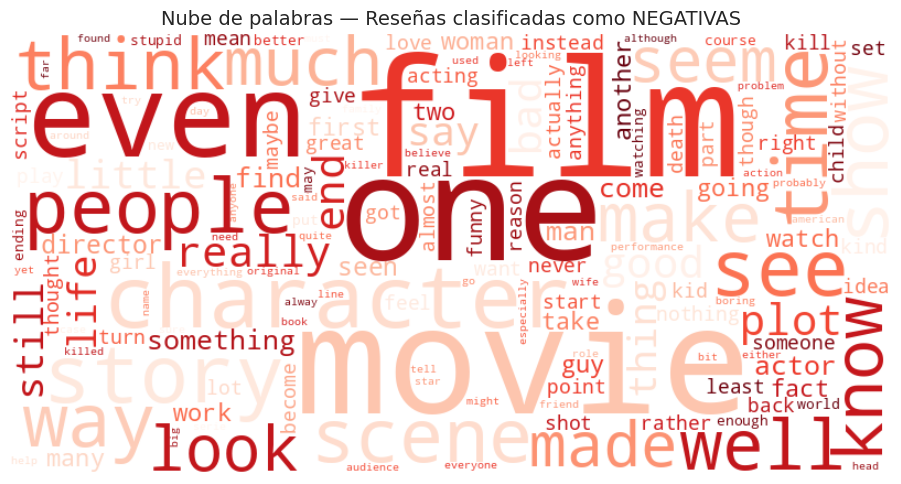

In [15]:
# Nube de palabras de las reseñas predichas como NEGATIVAS.
generar_wordcloud(
    texto_negativo,
    "Nube de palabras — Reseñas clasificadas como NEGATIVAS",
    "Reds",
)


### 7.4 Filtrado de palabras neutrales (vocabulario distintivo por clase)

Las dos nubes anteriores comparten gran parte de su vocabulario: términos como
*movie*, *film*, *one* o *character* aparecen con alta frecuencia tanto en reseñas
positivas como negativas, por lo que no aportan información de polaridad y terminan
dominando ambas imágenes.

Para resolverlo aplicamos un criterio de **distintividad léxica**: identificamos las
palabras frecuentes que son comunes a ambas clases y las consideramos *neutrales*.
El procedimiento es el siguiente. Primero calculamos la frecuencia de cada palabra por
separado en el corpus positivo y en el negativo. Luego tomamos el conjunto de las
palabras más frecuentes de cada clase y obtenemos su intersección: esas son las
palabras neutrales que ambas comparten. Finalmente las eliminamos del texto de cada
clase y regeneramos las nubes, de modo que solo sobreviva el vocabulario característico
de cada polaridad.


In [16]:
from collections import Counter

# 1) Contamos la frecuencia de cada palabra en cada clase predicha por separado.
#    Trabajamos sobre los tokens de 'review_limpia' ya preprocesados.
tokens_positivos = texto_positivo.split()
tokens_negativos = texto_negativo.split()

frec_positiva = Counter(tokens_positivos)
frec_negativa = Counter(tokens_negativos)

# 2) Tomamos el conjunto de las N palabras más frecuentes de cada clase.
#    N controla cuán estricto es el filtro: a mayor N, más palabras se evalúan.
TOP_N = 50

top_positivas = {palabra for palabra, _ in frec_positiva.most_common(TOP_N)}
top_negativas = {palabra for palabra, _ in frec_negativa.most_common(TOP_N)}

# 3) Las palabras NEUTRALES son las que aparecen en el top de AMBAS clases:
#    son frecuentes en positivas y en negativas, así que no discriminan polaridad.
palabras_neutrales = top_positivas & top_negativas

print(f"Cantidad de palabras consideradas neutrales: {len(palabras_neutrales)}")
print("Palabras neutrales detectadas (compartidas por ambas clases):")
print(sorted(palabras_neutrales))


Cantidad de palabras consideradas neutrales: 44
Palabras neutrales detectadas (compartidas por ambas clases):
['acting', 'actor', 'also', 'bad', 'character', 'could', 'end', 'even', 'film', 'first', 'get', 'good', 'know', 'life', 'like', 'little', 'look', 'made', 'make', 'man', 'many', 'movie', 'much', 'never', 'not', 'one', 'people', 'plot', 'really', 'say', 'scene', 'see', 'seen', 'show', 'story', 'thing', 'think', 'time', 'two', 'watch', 'way', 'well', 'would', 'year']


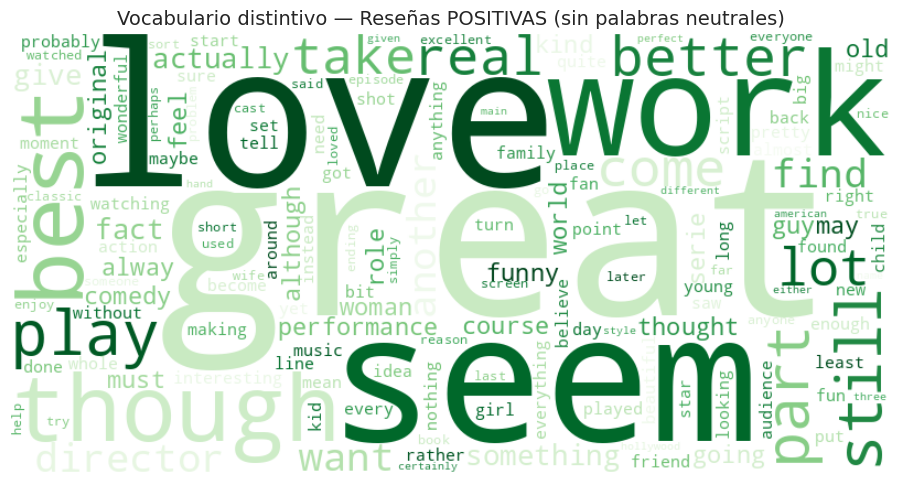

In [17]:
def quitar_neutrales(texto, neutrales):
    """Elimina del texto las palabras consideradas neutrales (compartidas)."""
    return " ".join(palabra for palabra in texto.split() if palabra not in neutrales)


# 4) Reconstruimos el texto de cada clase descartando las palabras neutrales.
texto_positivo_distintivo = quitar_neutrales(texto_positivo, palabras_neutrales)
texto_negativo_distintivo = quitar_neutrales(texto_negativo, palabras_neutrales)

# 5) Regeneramos ambas nubes, ahora con el vocabulario distintivo de cada polaridad.
generar_wordcloud(
    texto_positivo_distintivo,
    "Vocabulario distintivo — Reseñas POSITIVAS (sin palabras neutrales)",
    "Greens",
)


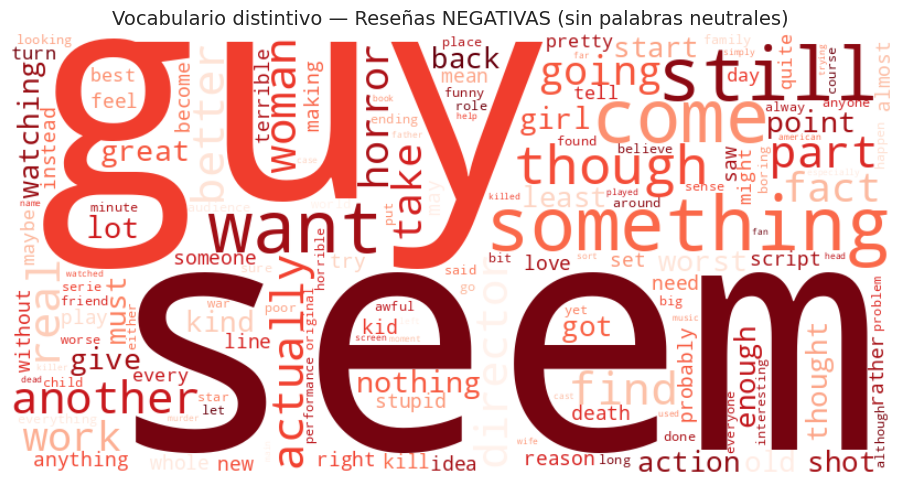

In [18]:
generar_wordcloud(
    texto_negativo_distintivo,
    "Vocabulario distintivo — Reseñas NEGATIVAS (sin palabras neutrales)",
    "Reds",
)


 ### 8. Significancia estadística: prueba de McNemar (Enfoque A vs. Enfoque B)
 Compara los dos clasificadores sobre EXACTAMENTE las mismas reseñas. La
 prueba de McNemar es el contraste correcto para clasificadores pareados:
 se fija solo en los casos discordantes (los que un enfoque acierta y el
 otro falla). Requiere que el DataFrame 'df' ya tenga las columnas:
   - sentiment        (etiqueta real / ground truth)
   - sent_limpia      (predicción del Enfoque A, texto preprocesado)
   - pred_sentiment   (predicción del Enfoque B, texto crudo)


In [19]:
from math import erfc, sqrt

# Aciertos pareados de cada enfoque frente a la etiqueta real.
acierta_A = (df["sent_limpia"] == df["sentiment"]).to_numpy()
acierta_B = (df["pred_sentiment"] == df["sentiment"]).to_numpy()

# Tabla de contingencia 2x2 (aciertos/errores pareados).
ambos_ok   = int((acierta_A & acierta_B).sum())
ambos_mal  = int((~acierta_A & ~acierta_B).sum())
b = int((acierta_A & ~acierta_B).sum())   # A acierta, B falla
c = int((~acierta_A & acierta_B).sum())   # A falla,  B acierta
n = len(df)

# Estadístico de McNemar con corrección de continuidad y su valor p
# (chi-cuadrado con 1 g.l.; P(X > x) = erfc(sqrt(x/2)), sin dependencias).
chi2 = (abs(b - c) - 1) ** 2 / (b + c)
p_valor = erfc(sqrt(chi2 / 2.0))

print("Prueba de McNemar — Enfoque A (preprocesado) vs. Enfoque B (crudo)")
print("-" * 66)
print("Tabla de contingencia pareada:")
print(f"  A acierta & B acierta : {ambos_ok:>6}")
print(f"  A acierta & B falla   : {b:>6}   (b)")
print(f"  A falla   & B acierta : {c:>6}   (c)")
print(f"  A falla   & B falla   : {ambos_mal:>6}")
print(f"  Discordantes (b + c)  : {b + c:>6}")
print(f"  Suma de verificación  : {ambos_ok + ambos_mal + b + c} (= {n})")
print("-" * 66)
print(f"Mejora neta de B (c - b): {c - b} reseñas ({100 * (c - b) / n:.2f}% del corpus)")
print(f"Chi2 de McNemar (c.c.)  : {chi2:.4f}  (1 g.l.)")
print(f"Valor p                 : {p_valor:.3e}")

# Verificación opcional con la prueba binomial exacta (si scipy está disponible).
try:
    from scipy.stats import binomtest
    p_exacto = binomtest(min(b, c), b + c, 0.5, alternative="two-sided").pvalue
    print(f"Valor p (binomial exacto): {p_exacto:.3e}")
except ImportError:
    pass

print("-" * 66)
if p_valor < 0.05:
    print("Conclusión: p < 0.05 -> se RECHAZA la hipótesis nula de igual desempeño.")
    print("La ventaja del texto crudo sobre el preprocesado es estadísticamente")
    print("significativa y no atribuible al azar; se acepta la hipótesis de trabajo.")
else:
    print("Conclusión: p >= 0.05 -> no hay evidencia para rechazar la igualdad.")

Prueba de McNemar — Enfoque A (preprocesado) vs. Enfoque B (crudo)
------------------------------------------------------------------
Tabla de contingencia pareada:
  A acierta & B acierta :  31429
  A acierta & B falla   :   2356   (b)
  A falla   & B acierta :   3240   (c)
  A falla   & B falla   :  12557
  Discordantes (b + c)  :   5596
  Suma de verificación  : 49582 (= 49582)
------------------------------------------------------------------
Mejora neta de B (c - b): 884 reseñas (1.78% del corpus)
Chi2 de McNemar (c.c.)  : 139.3297  (1 g.l.)
Valor p                 : 3.731e-32
Valor p (binomial exacto): 2.786e-32
------------------------------------------------------------------
Conclusión: p < 0.05 -> se RECHAZA la hipótesis nula de igual desempeño.
